In [2]:
# =============================
# Install (usually already available)
# =============================
!pip install -q kagglehub

# =============================
# Imports
# =============================
import os
import tensorflow as tf
import kagglehub

from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model

# =============================
# Enable mixed precision (faster on GPU)
# =============================
mixed_precision.set_global_policy('mixed_float16')

print("GPU:", tf.config.list_physical_devices('GPU'))

# =============================
# Download dataset
# =============================
dataset_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

BASE_DIR = os.path.join(
    dataset_path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)"
)

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "valid")

print("Dataset loaded from:", BASE_DIR)

# =============================
# Load dataset
# =============================
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 8
IMG_SIZE = (224,224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)

# =============================
# Dataset optimization
# =============================
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# =============================
# Model (EfficientNetB0)
# =============================
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation="softmax", dtype="float32")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =============================
# Train
# =============================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# =============================
# Save model (New Keras format)
# =============================
model.save("/kaggle/working/plant_disease_model.keras")

print("Model saved!")

# =============================
# Download model
# =============================
from IPython.display import FileLink
FileLink('/kaggle/working/plant_disease_model.keras')

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Dataset loaded from: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
Found 70295 files belonging to 38 classes.


I0000 00:00:1773552512.006046      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773552512.012515      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 17572 files belonging to 38 classes.
Number of classes: 38
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

...

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/10


I0000 00:00:1773552552.181543     188 service.cc:152] XLA service 0x7cb6c00137b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773552552.181578     188 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773552552.181582     188 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773552554.634177     188 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773552583.697524     188 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8787/8787 ━━━━━━━━━━━━━━━━━━━━ 308s 27ms/step - accuracy: 0.6186 - loss: 1.4116 - val_accuracy: 0.9578 - val_loss: 0.1327
Epoch 2/10
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 100s 11ms/step - accuracy: 0.8964 - loss: 0.3265 - val_accuracy: 0.9725 - val_loss: 0.0877
Epoch 3/10
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 99s 11ms/step - accuracy: 0.9243 - loss: 0.2284 - val_accuracy: 0.9762 - val_loss: 0.0722
Epoch 4/10
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 99s 11ms/step - accuracy: 0.9355 - loss: 0.1968 - val_accuracy: 0.9795 - val_loss: 0.0617
Epoch 5/10
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 100s 11ms/step - accuracy: 0.9467 - loss: 0.1673 - val_accuracy: 0.9824 - val_loss: 0.0554
Epoch 6/10
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 100s 11ms/step - accuracy: 0.9475 - loss: 0.1583 - val_accuracy: 0.9816 - val_loss: 0.0557
Epoch 7/10
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 99s 11ms/step - accuracy: 0.9526 - loss: 0.1446 - val_accuracy: 0.9837 - val_loss: 0.0502
Epoch 8/10
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 100s 11ms/step - accuracy: 0.9543 - loss:

/kaggle/working/plant_disease_model.keras

# Testing and Predicting


Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Predicted Disease: Tomato___healthy
Confidence: 99.99 %


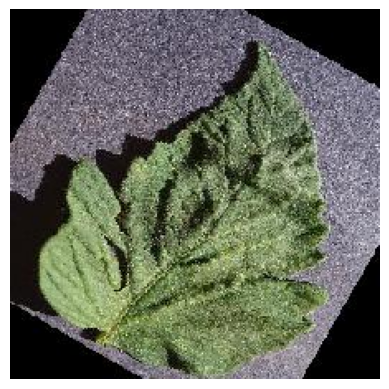

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# =============================
# Load trained model
# =============================
model = tf.keras.models.load_model(
    "/kaggle/working/plant_disease_model.keras",
    compile=False
)

print("Model loaded successfully!")

# =============================
# Class names
# =============================
class_names = [
'Apple___Apple_scab','Apple___Black_rot','Apple___Cedar_apple_rust','Apple___healthy',
'Blueberry___healthy','Cherry_(including_sour)___Powdery_mildew','Cherry_(including_sour)___healthy',
'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot','Corn_(maize)___Common_rust_',
'Corn_(maize)___Northern_Leaf_Blight','Corn_(maize)___healthy','Grape___Black_rot',
'Grape___Esca_(Black_Measles)','Grape___Leaf_blight_(Isariopsis_Leaf_Spot)','Grape___healthy',
'Orange___Haunglongbing_(Citrus_greening)','Peach___Bacterial_spot','Peach___healthy',
'Pepper,_bell___Bacterial_spot','Pepper,_bell___healthy','Potato___Early_blight',
'Potato___Late_blight','Potato___healthy','Raspberry___healthy','Soybean___healthy',
'Squash___Powdery_mildew','Strawberry___Leaf_scorch','Strawberry___healthy',
'Tomato___Bacterial_spot','Tomato___Early_blight','Tomato___Late_blight',
'Tomato___Leaf_Mold','Tomato___Septoria_leaf_spot','Tomato___Spider_mites Two-spotted_spider_mite',
'Tomato___Target_Spot','Tomato___Tomato_Yellow_Leaf_Curl_Virus',
'Tomato___Tomato_mosaic_virus','Tomato___healthy'
]

# =============================
# Load image
# =============================
img_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/TomatoHealthy3.JPG"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

# =============================
# Predict
# =============================
predictions = model.predict(img_array)

pred_index = np.argmax(predictions)
confidence = predictions[0][pred_index]

predicted_class = class_names[pred_index]

# =============================
# Show result
# =============================
plt.imshow(img)
plt.axis("off")

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence*100,2), "%")